# 3. MNIST and CNN Experiments [3 marks]
This section explores deep learning for images. You will train MLPs and CNNs on MNIST, compare performance against baseline models, visualize embeddings using t-SNE, and test cross-domain generalization on Fashion-MNIST.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
from torchvision import models

In [3]:
if torch.cuda.is_available():
  device = torch.device("cuda")
elif torch.backends.mps.is_available():
  device = torch.device("mps")
else:
  device = torch.device("cpu")

print(f"Using: {device}")

Using: cuda


In [ ]:
# Download MNIST and Fashion-MNIST datasets using torchvision

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
mnist_val = torch.utils.data.Subset(mnist_train, range(55000, 60000))
mnist_train = torch.utils.data.Subset(mnist_train, range(0, 50000))

fashion_mnist_train = datasets.FashionMNIST(root='./data', train=True, download=True, transform = transform)
fashion_mnist_test = datasets.FashionMNIST(root='./data', train=False, download=True, transform = transform)
fashion_mnist_val = torch.utils.data.Subset(fashion_mnist_train, range(55000, 60000))
fashion_mnist_train = torch.utils.data.Subset(fashion_mnist_train, range(0, 50000))

In [5]:
mnist_train_dataloader = DataLoader(mnist_train, batch_size=64, shuffle=True)
mnist_val_dataloader = DataLoader(mnist_val, batch_size=64, shuffle=True)
mnist_test_dataloader = DataLoader(mnist_test, batch_size=64, shuffle=True)

fashion_mnist_train_dataloader = DataLoader(fashion_mnist_train, batch_size=64, shuffle=True)
fashion_mnist_val_dataloader = DataLoader(fashion_mnist_val, batch_size=64, shuffle=True)
fashion_mnist_test_dataloader = DataLoader(fashion_mnist_test, batch_size=64, shuffle=True)

torch.Size([64, 1, 224, 224])
torch.Size([64])


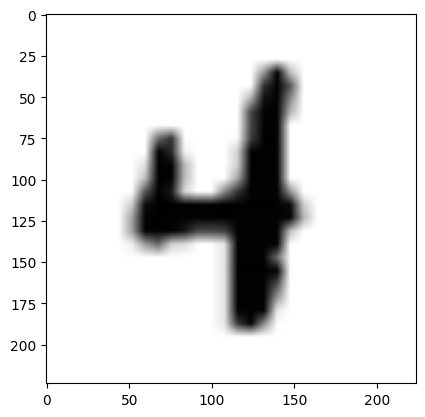

In [7]:
import matplotlib.pyplot as plt
import numpy as np

img, target = next(iter(mnist_train_dataloader))
print(img.shape)
print(target.shape)
plt.imshow(img[17].numpy().squeeze(), cmap = 'gray_r')

In [6]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import seaborn as sns
import time
import os

def evaluate_model(model, dataloader, device, model_name):
    model.eval()
    model.to(device)

    temp_path = f"{model_name}_temp.pth"
    torch.save(model.state_dict(), temp_path)
    model_size_mb = os.path.getsize(temp_path) / (1024 * 1024)
    os.remove(temp_path)

    y_true = []
    y_pred = []
    total_infer_time = 0.0
    total_samples = 0

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)

            start_time = time.time()
            outputs = model(data)
            end_time = time.time()

            total_infer_time += (end_time - start_time)
            total_samples += data.size(0)

            _, predicted = torch.max(outputs, 1)
            y_true.extend(target.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')

    cm = confusion_matrix(y_true, y_pred)
    avg_infer_time_ms = (total_infer_time / total_samples) * 1000  # ms per image

    print(f"\n{model_name} -  Evaluation Results:")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"F1-Score (macro): {f1*100:.2f}%")
    print(f"Model Size: {model_size_mb:.2f} MB")
    print(f"Avg Inference Time: {avg_infer_time_ms:.3f} ms/image")

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    return acc, f1, cm, model_size_mb, avg_infer_time_ms


In [7]:
def train_loop(train_loader, val_loader, model, loss_fn, optimizer, n_epochs = 10, device = 'cpu'):
    train_losses = []
    val_losses = []
    prev_train_loss = float('inf')

    for epoch in range(n_epochs):
        train_loss = 0.0
        val_loss = 0.0


        # Train the model
        model.train()
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = loss_fn(output, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()*data.size(0)

        # Evaluate the model
        model.eval()
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = loss_fn(output, target)
            val_loss += loss.item()*data.size(0)

        # Calculate average losses
        train_loss = train_loss/len(train_loader.sampler)
        val_loss = val_loss/len(val_loader.sampler)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Print training/validation statistics
        print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
          epoch+1,
          train_loss,
          val_loss
          ))

        # stopping criteria
        if prev_train_loss - train_loss < 0.001:
          break
        prev_train_loss = train_loss

    return train_losses, val_losses

# 3.1 Using MLP
Train on MNIST dataset using an MLP. The original training dataset contains 60,000 images and the test contains 10,000 images. If you are short on compute, use a stratified subset of a smaller number of images but keep the same test set. Your MLP has 30 neurons in the first layer, 20 in the second layer and then 10 finally for the output layer (corresponding to 10 classes)

In [30]:
class SimpleMLP(nn.Module):
    def __init__(self, img_height, img_width):
        super(SimpleMLP, self).__init__()
        self.img_height = img_height
        self.img_width = img_width

        self.fc1 = nn.Linear(img_height*img_width, 30)
        self.fc2 = nn.Linear(30, 20)
        self.fc3 = nn.Linear(20, 10)

    def forward(self, x):
        x = x.view(-1, self.img_height * self.img_width)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [31]:
mlp = SimpleMLP(224, 224)
mlp.to(device)

SimpleMLP(
  (fc1): Linear(in_features=50176, out_features=30, bias=True)
  (fc2): Linear(in_features=30, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=10, bias=True)
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp.parameters(), lr=1e-4)

mlp_train_losses, mlp_val_losses = train_loop(mnist_train_dataloader, mnist_val_dataloader, mlp, loss_fn, optimizer, n_epochs = 10, device = device)

Epoch: 1 	Training Loss: 0.588935 	Validation Loss: 0.232801
Epoch: 2 	Training Loss: 0.280589 	Validation Loss: 0.183414
Epoch: 3 	Training Loss: 0.233155 	Validation Loss: 0.158948
Epoch: 4 	Training Loss: 0.206056 	Validation Loss: 0.150192
Epoch: 5 	Training Loss: 0.184914 	Validation Loss: 0.137110
Epoch: 6 	Training Loss: 0.168282 	Validation Loss: 0.130483
Epoch: 7 	Training Loss: 0.155561 	Validation Loss: 0.129560
Epoch: 8 	Training Loss: 0.145926 	Validation Loss: 0.122593
Epoch: 9 	Training Loss: 0.136723 	Validation Loss: 0.122692
Epoch: 10 	Training Loss: 0.129345 	Validation Loss: 0.123383


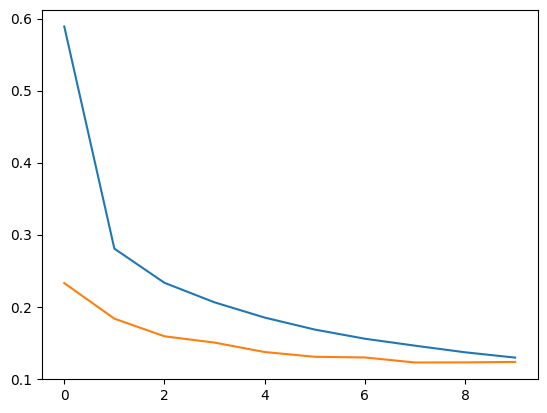

In [ ]:
plt.plot(mlp_train_losses, label='Training loss')
plt.plot(mlp_val_losses, label='Validation loss')


MLP -  Evaluation Results:
Accuracy: 95.74%
F1-Score (macro): 95.68%
Model Size: 5.75 MB
Avg Inference Time: 0.005 ms/image


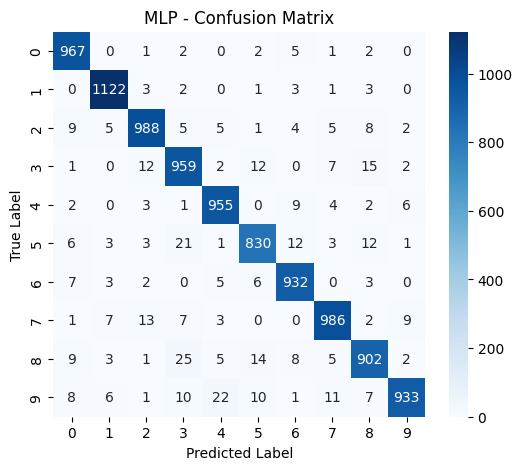

In [ ]:
acc_mlp, f1_mlp, cm_mlp, model_size_mb_mlp, avg_infer_time_ms_mlp = evaluate_model(mlp, mnist_test_dataloader, device, "MLP")

In [ ]:
torch.save(mlp.state_dict(), "mnist_mlp_50k.pth")

## Report the following:

1. Compare against Random Forest and Logistic Regression. The metrics can be: accuracy, F1-score, confusion matrix. Write your observations and discuss misclassifications.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

def prepare_sklearn_data(dataloader):
    X = []
    y = []
    for data, target in dataloader:
        data = data.view(data.size(0), -1)  # Flatten the images
        X.append(data.numpy())
        y.append(target.numpy())
    X = np.vstack(X)
    y = np.hstack(y)
    return X, y

X_train, y_train = prepare_sklearn_data(mnist_train_dataloader)
X_val, y_val = prepare_sklearn_data(mnist_val_dataloader)
X_test, y_test = prepare_sklearn_data(mnist_test_dataloader)

In [ ]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


Random Forest -  Evaluation Results:
Accuracy: 96.72%
F1-Score (macro): 96.69%


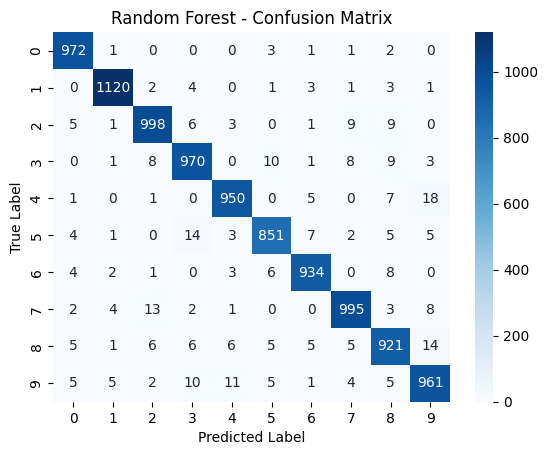

In [ ]:
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(f"\nRandom Forest -  Evaluation Results:")
print(f"Accuracy: {acc_rf*100:.2f}%")
print(f"F1-Score (macro): {f1_rf*100:.2f}%")

cm_sns = sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
class MulticlassLogisticRegression(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super(MulticlassLogisticRegression, self).__init__()
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs
        self.linear = nn.Linear(n_inputs, n_outputs)

    def forward(self, x):
        x = x.view(-1, self.n_inputs)
        y_pred = self.linear(x)
        return y_pred

In [ ]:
lr_model = MulticlassLogisticRegression(224*224, 10)
lr_model.to(device)

MulticlassLogisticRegression(
  (linear): Linear(in_features=50176, out_features=10, bias=True)
)

In [ ]:
loss_fn = nn.CrossEntropyLoss() # Combines a Sigmoid layer and the BCELoss in one single class.
optimizer = optim.SGD(lr_model.parameters(), lr=0.001)

In [ ]:
lr_train_losses, lr_val_losses = train_loop(mnist_train_dataloader, mnist_val_dataloader, lr_model, loss_fn, optimizer, n_epochs = 50, device = device)

Epoch: 1 	Training Loss: 0.584136 	Validation Loss: 0.333054
Epoch: 2 	Training Loss: 0.384941 	Validation Loss: 0.290044
Epoch: 3 	Training Loss: 0.353968 	Validation Loss: 0.273532
Epoch: 4 	Training Loss: 0.338205 	Validation Loss: 0.266023
Epoch: 5 	Training Loss: 0.328464 	Validation Loss: 0.258562
Epoch: 6 	Training Loss: 0.320879 	Validation Loss: 0.253870
Epoch: 7 	Training Loss: 0.315369 	Validation Loss: 0.250871
Epoch: 8 	Training Loss: 0.311074 	Validation Loss: 0.247497
Epoch: 9 	Training Loss: 0.307336 	Validation Loss: 0.244522
Epoch: 10 	Training Loss: 0.304328 	Validation Loss: 0.241613
Epoch: 11 	Training Loss: 0.301767 	Validation Loss: 0.241680
Epoch: 12 	Training Loss: 0.299589 	Validation Loss: 0.239920
Epoch: 13 	Training Loss: 0.297432 	Validation Loss: 0.238422
Epoch: 14 	Training Loss: 0.295613 	Validation Loss: 0.238000
Epoch: 15 	Training Loss: 0.293968 	Validation Loss: 0.236628
Epoch: 16 	Training Loss: 0.292507 	Validation Loss: 0.235131
Epoch: 17 	Traini

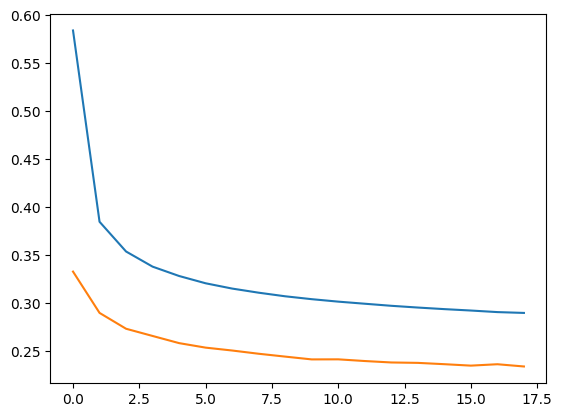

In [ ]:
plt.plot(lr_train_losses, label='Training loss')
plt.plot(lr_val_losses, label='Validation loss')


Multiclass Logistic Regression -  Evaluation Results:
Accuracy: 92.22%
F1-Score (macro): 92.10%
Model Size: 1.92 MB
Avg Inference Time: 0.002 ms/image


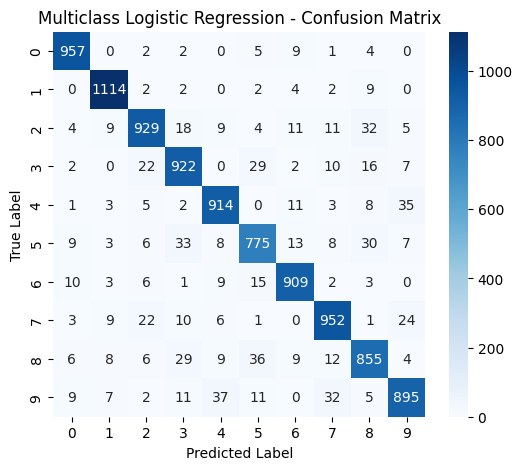

(0.9222,
 0.9209683316994782,
 array([[ 957,    0,    2,    2,    0,    5,    9,    1,    4,    0],
        [   0, 1114,    2,    2,    0,    2,    4,    2,    9,    0],
        [   4,    9,  929,   18,    9,    4,   11,   11,   32,    5],
        [   2,    0,   22,  922,    0,   29,    2,   10,   16,    7],
        [   1,    3,    5,    2,  914,    0,   11,    3,    8,   35],
        [   9,    3,    6,   33,    8,  775,   13,    8,   30,    7],
        [  10,    3,    6,    1,    9,   15,  909,    2,    3,    0],
        [   3,    9,   22,   10,    6,    1,    0,  952,    1,   24],
        [   6,    8,    6,   29,    9,   36,    9,   12,  855,    4],
        [   9,    7,    2,   11,   37,   11,    0,   32,    5,  895]]),
 1.916264533996582,
 0.0015761852264404297)

In [ ]:
evaluate_model(lr_model, mnist_test_dataloader, device, "Multiclass Logistic Regression")

We trained a Random Forest Classifier and a Multiclass Logistic Regression Model. The Random Forest Classifier is trained with 100 estimators & the Logistic Regression model is trained with SGD optimizer for 50 epochs, until the stopping condition cuts if off.

The Logistic Regression models converges smoothly with SGD optimizer.

The random forest classifier does well in classifying digits, but it misclassifies similar digits such as 4 & 9, 3 & 8.

2. Visualize t-SNE of the 20-neuron layer for the 10 digits for the trained and untrained model and compare the two.


In [ ]:
mlp_untrained = SimpleMLP(224, 224)
mlp_untrained.to(device)

SimpleMLP(
  (fc1): Linear(in_features=50176, out_features=30, bias=True)
  (fc2): Linear(in_features=30, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=10, bias=True)
)

In [ ]:
mlp_second_layer_untrained = nn.Sequential(
    mlp_untrained.fc1,
    nn.ReLU(),
    mlp_untrained.fc2
)

mlp_second_layer_trained = nn.Sequential(
    mlp.fc1,
    nn.ReLU(),
    mlp.fc2
)

In [ ]:
E_1 = []
E_2 = []
y = []

for data, target in mnist_train_dataloader:
    data = data.view(data.size(0), -1)
    with torch.no_grad():
        emb1 = mlp_second_layer_untrained(data.to(device)).cpu().numpy()
        emb2 = mlp_second_layer_trained(data.to(device)).cpu().numpy()

    E_1.append(emb1)
    E_2.append(emb2)
    y.append(target.numpy())

E_1 = np.vstack(E_1)
E_2 = np.vstack(E_2)
y = np.hstack(y)

In [ ]:
print(E_1.shape)
print(E_2.shape)
print(y.shape)

(50000, 20)
(50000, 20)
(50000,)


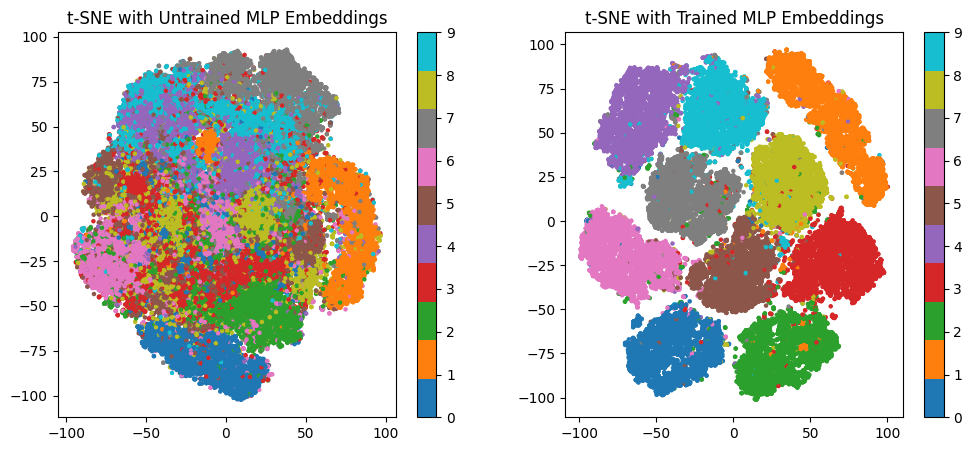

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
projected_E_1 = tsne.fit_transform(E_1)
projected_E_2 = tsne.fit_transform(E_2)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(projected_E_1[:, 0], projected_E_1[:, 1], c=y, cmap='tab10', s=5)
plt.title('t-SNE with Untrained MLP Embeddings')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.scatter(projected_E_2[:, 0], projected_E_2[:, 1], c=y, cmap='tab10', s=5)
plt.title('t-SNE with Trained MLP Embeddings')
plt.colorbar()
plt.show()



3. Test the trained MLP on Fashion-MNIST dataset. What do you observe? Compare t-SNE plots for MNIST and Fashion-MNIST embeddings for the layer with 20 neurons.


MNIST-MLP on Fashion-MNIST -  Evaluation Results:
Accuracy: 3.20%
F1-Score (macro): 2.26%
Model Size: 5.75 MB
Avg Inference Time: 0.005 ms/image


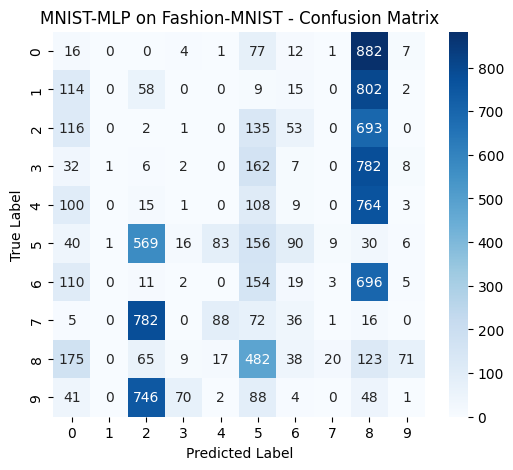

(0.032,
 0.02263748789953805,
 array([[ 16,   0,   0,   4,   1,  77,  12,   1, 882,   7],
        [114,   0,  58,   0,   0,   9,  15,   0, 802,   2],
        [116,   0,   2,   1,   0, 135,  53,   0, 693,   0],
        [ 32,   1,   6,   2,   0, 162,   7,   0, 782,   8],
        [100,   0,  15,   1,   0, 108,   9,   0, 764,   3],
        [ 40,   1, 569,  16,  83, 156,  90,   9,  30,   6],
        [110,   0,  11,   2,   0, 154,  19,   3, 696,   5],
        [  5,   0, 782,   0,  88,  72,  36,   1,  16,   0],
        [175,   0,  65,   9,  17, 482,  38,  20, 123,  71],
        [ 41,   0, 746,  70,   2,  88,   4,   0,  48,   1]]),
 5.7486467361450195,
 0.004605722427368164)

In [ ]:
evaluate_model(mlp, fashion_mnist_test_dataloader, device, "MNIST-MLP on Fashion-MNIST")

In [ ]:
E_1 = []
y_1 = []

for data, target in mnist_train_dataloader:
    data = data.view(data.size(0), -1)
    with torch.no_grad():
        emb1 = mlp_second_layer_trained(data.to(device)).cpu().numpy()
    E_1.append(emb1)
    y_1.append(target.numpy())

E_1 = np.vstack(E_1)
y_1 = np.hstack(y_1)

In [ ]:
E_2 = []
y_2 = []

for data, target in fashion_mnist_train_dataloader:
    data = data.view(data.size(0), -1)
    with torch.no_grad():
        emb2 = mlp_second_layer_trained(data.to(device)).cpu().numpy()
    E_2.append(emb2)
    y_2.append(target.numpy())

E_2 = np.vstack(E_2)
y_2 = np.hstack(y_2)

In [ ]:
print(E_1.shape)
print(E_2.shape)
print(y_1.shape)
print(y_2.shape)

(50000, 20)
(50000, 20)
(50000,)
(50000,)


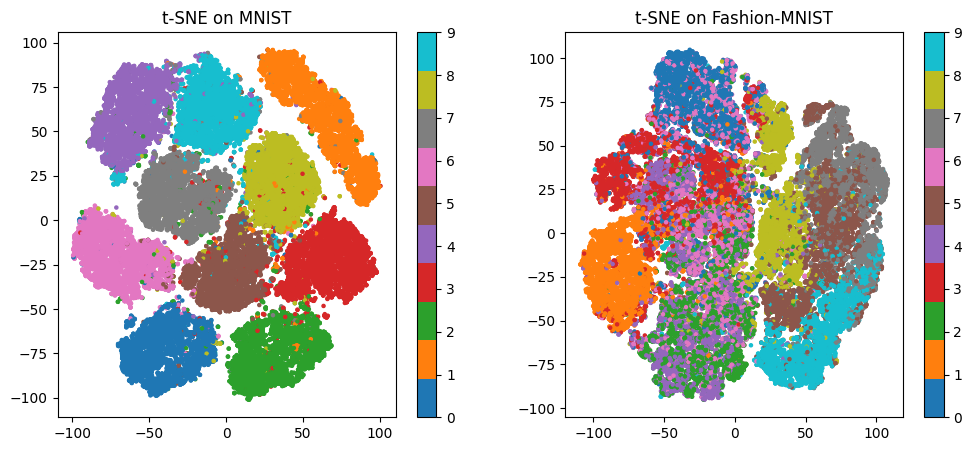

In [ ]:
projected_E_1 = tsne.fit_transform(E_1)
projected_E_2 = tsne.fit_transform(E_2)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(projected_E_1[:, 0], projected_E_1[:, 1], c=y_1, cmap='tab10', s=5)
plt.title('t-SNE on MNIST')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.scatter(projected_E_2[:, 0], projected_E_2[:, 1], c=y_2, cmap='tab10', s=5)
plt.title('t-SNE on Fashion-MNIST')
plt.colorbar()
plt.show()

The MLP model trained on MNIST dataset clearly performs poorly on the out-of- distribution test set from the Fashion MNIST dataset.

# 3.2 Using CNN

Implement a simple CNN with a convolutional layer having 32 filters of size 3x3, a maxpool layer, a fully connected layer with 128 neurons and an output layer with 10 neurons (for the 10 classes) and ReLU activation. Train on MNIST dataset.

In [25]:
class ConvNet(nn.Module):
    def __init__(self, img_height, img_width):
        super(ConvNet, self).__init__()
        # 1 input image channel, 32 output channels, 3x3 square convolution
        self.conv = nn.Conv2d(1, 32, 3)
        self.fc1 = nn.Linear(32*111*111, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv(x) # 224x224x1 -> 222x222x32
        x = F.max_pool2d(F.relu(x), 2) # 222x222x32 -> 111x111x32

        x = x.view(-1, self.num_flat_features(x)) # 111x111x32 -> 394272
        x = self.fc1(x) # 394272 -> 128
        x = F.relu(x)
        x = self.fc2(x) # 128 -> 10
        return x

    def num_flat_features(self, x):
        size = x.size()[1:]
        num_features = 1
        for s in size:
            num_features *= s
        return num_features

In [26]:
cnn = ConvNet(224, 224)
cnn.to(device)

ConvNet(
  (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=394272, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [27]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=0.001)

cnn_train_losses, cnn_val_losses = train_loop(mnist_train_dataloader, mnist_val_dataloader, cnn, loss_fn, optimizer, n_epochs = 10, device=device)

Epoch: 1 	Training Loss: 0.760989 	Validation Loss: 0.198151
Epoch: 2 	Training Loss: 0.249010 	Validation Loss: 0.165770
Epoch: 3 	Training Loss: 0.197623 	Validation Loss: 0.147799
Epoch: 4 	Training Loss: 0.164269 	Validation Loss: 0.129758
Epoch: 5 	Training Loss: 0.142453 	Validation Loss: 0.128568
Epoch: 6 	Training Loss: 0.123220 	Validation Loss: 0.103618
Epoch: 7 	Training Loss: 0.101697 	Validation Loss: 0.109660
Epoch: 8 	Training Loss: 0.083515 	Validation Loss: 0.094105
Epoch: 9 	Training Loss: 0.066434 	Validation Loss: 0.086836
Epoch: 10 	Training Loss: 0.053372 	Validation Loss: 0.093336


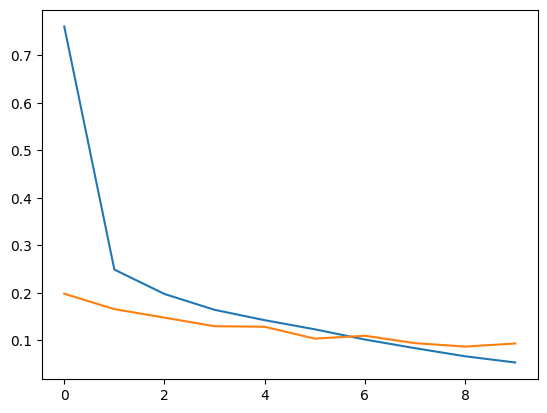

In [28]:
import matplotlib.pyplot as plt

plt.plot(cnn_train_losses, label='Training loss')
plt.plot(cnn_val_losses, label='Validation loss')


CNN -  Evaluation Results:
Accuracy: 97.19%
F1-Score (macro): 97.17%
Model Size: 192.53 MB
Avg Inference Time: 0.007 ms/image


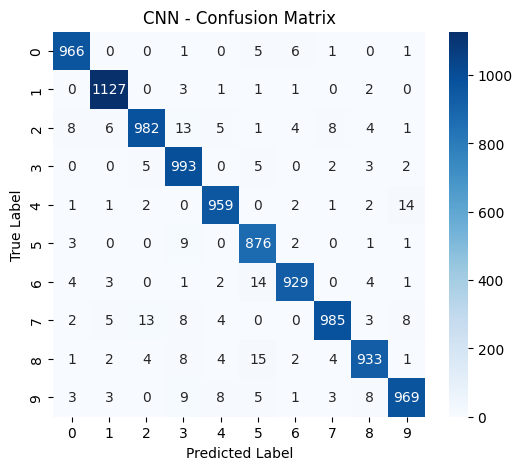

In [29]:
acc_cnn, f1_cnn, cm_cnn, model_size_mb_cnn, avg_infer_time_ms_cnn = evaluate_model(cnn, mnist_test_dataloader, device, "CNN")

In [ ]:
torch.save(cnn.state_dict(), "mnist_cnn_50k.pth")

Additionally, use two any pretrained CNNs of your choice (e.g. AlexNet, MobileNet, or EfficientNet) for inference.


## Using AlexNet

In [ ]:
alexnet = models.alexnet(pretrained=True)
alexnet.features[0] = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=11,
    stride=4,
    padding=2
)
alexnet.classifier[6] = nn.Linear(alexnet.classifier[6].in_features, 10)

In [ ]:
alexnet.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
optimizer = optim.Adam(alexnet.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

alexnet_train_losses, alexnet_val_losses = train_loop(mnist_train_dataloader, mnist_val_dataloader, alexnet, loss_fn, optimizer, n_epochs =10, device=device)

Epoch: 1 	Training Loss: 0.463599 	Validation Loss: 0.075901
Epoch: 2 	Training Loss: 0.110783 	Validation Loss: 0.056590
Epoch: 3 	Training Loss: 0.084126 	Validation Loss: 0.039227
Epoch: 4 	Training Loss: 0.077743 	Validation Loss: 0.036302
Epoch: 5 	Training Loss: 0.065015 	Validation Loss: 0.041984
Epoch: 6 	Training Loss: 0.063162 	Validation Loss: 0.039975
Epoch: 7 	Training Loss: 0.052046 	Validation Loss: 0.041833
Epoch: 8 	Training Loss: 0.049393 	Validation Loss: 0.036726
Epoch: 9 	Training Loss: 0.048233 	Validation Loss: 0.025702
Epoch: 10 	Training Loss: 0.047995 	Validation Loss: 0.030807


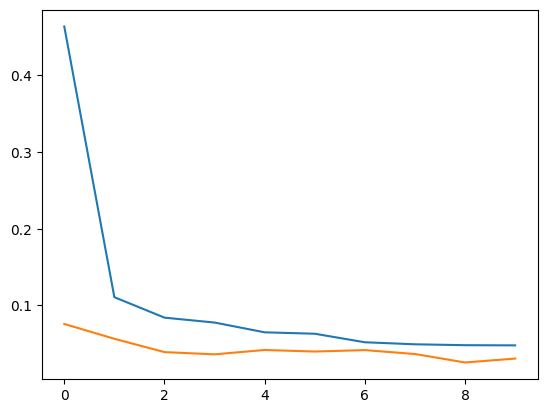

In [ ]:
plt.plot(alexnet_train_losses, label='Training loss')
plt.plot(alexnet_val_losses, label='Validation loss')


AlexNet -  Evaluation Results:
Accuracy: 98.96%
F1-Score (macro): 98.96%
Model Size: 217.56 MB
Avg Inference Time: 0.013 ms/image


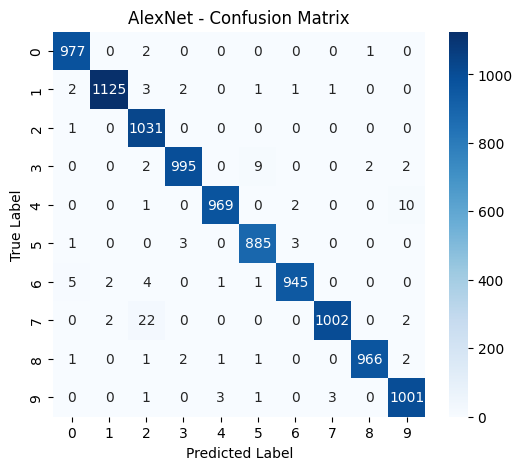

In [ ]:
acc_alex, f1_alex, cm_alex, model_size_mb_alex, avg_infer_time_ms_alex = evaluate_model(alexnet, mnist_test_dataloader, device, "AlexNet")

In [ ]:
torch.save(alexnet.state_dict(), "mnist_alexnet_50k.pth")

## Using MobileNet

In [ ]:
mobilenet = models.mobilenet.mobilenet_v2(pretrained=True)
mobilenet.eval()

In [11]:
for param in mobilenet.parameters():
    param.requires_grad = False

In [12]:
mobilenet.features[0][0] = nn.Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
mobilenet.classifier[1] = nn.Linear(in_features=mobilenet.classifier[1].in_features, out_features=10)
mobilenet.to(device)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [13]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(mobilenet.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0001)


mobilenet_train_losses, mobilenet_val_losses = train_loop(mnist_train_dataloader, mnist_val_dataloader, mobilenet, loss_fn, optimizer, n_epochs =10, device=device)

Epoch: 1 	Training Loss: 0.677653 	Validation Loss: 0.290419
Epoch: 2 	Training Loss: 0.305519 	Validation Loss: 0.204322
Epoch: 3 	Training Loss: 0.245023 	Validation Loss: 0.163952
Epoch: 4 	Training Loss: 0.213153 	Validation Loss: 0.151583
Epoch: 5 	Training Loss: 0.194244 	Validation Loss: 0.130227
Epoch: 6 	Training Loss: 0.181630 	Validation Loss: 0.124721
Epoch: 7 	Training Loss: 0.173454 	Validation Loss: 0.118149
Epoch: 8 	Training Loss: 0.161820 	Validation Loss: 0.114133
Epoch: 9 	Training Loss: 0.157413 	Validation Loss: 0.110834
Epoch: 10 	Training Loss: 0.149823 	Validation Loss: 0.098819


Running for additional number of epochs. Continuing from last checkpoint.

In [20]:
addl_mobilenet_train_losses, addl_mobilenet_val_losses = train_loop(mnist_train_dataloader, mnist_val_dataloader, mobilenet, loss_fn, optimizer, n_epochs =20, device=device)

Epoch: 1 	Training Loss: 0.125064 	Validation Loss: 0.089216
Epoch: 2 	Training Loss: 0.124097 	Validation Loss: 0.081933


In [21]:
mobilenet_train_losses.extend(addl_mobilenet_train_losses)
mobilenet_val_losses.extend(addl_mobilenet_val_losses)

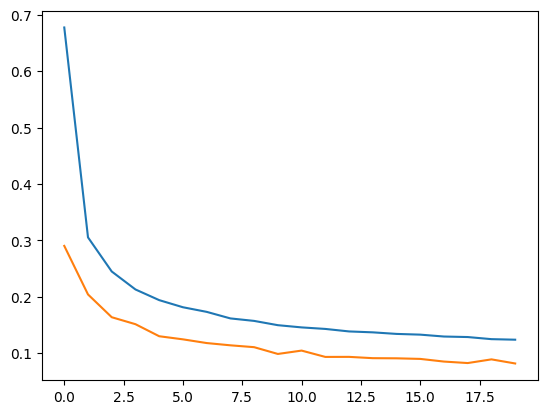

In [22]:
plt.plot(mobilenet_train_losses, label='Training loss')
plt.plot(mobilenet_val_losses, label='Validation loss')


MobileNetV2 -  Evaluation Results:
Accuracy: 97.24%
F1-Score (macro): 97.21%
Model Size: 8.77 MB
Avg Inference Time: 0.095 ms/image


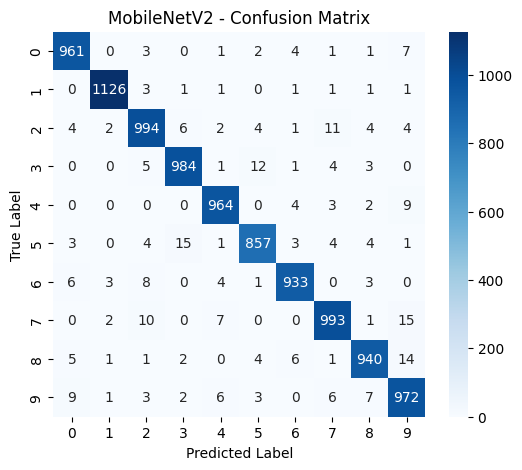

In [23]:
acc_mobilenet, f1_mobilenet, cm_mobilenet, model_size_mb_mobilenet, avg_infer_time_ms_mobilenet = evaluate_model(mobilenet, mnist_test_dataloader, device, "MobileNetV2")

In [ ]:
torch.save(mobilenet.state_dict(), "mnist_mobilenet_50k.pth")